In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

%matplotlib inline

In [2]:
from google.colab import files

uploaded = files.upload()

Saving mauna_loa_co2_monthly_mean_data.csv to mauna_loa_co2_monthly_mean_data.csv


In [3]:
import io

file_name = list(uploaded.keys())[0]

df = pd.read_csv(
    io.BytesIO(uploaded[file_name]),
    comment='#'
)

df.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99


In [4]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Dataset shape: (804, 8)

Column names:
Index(['year', 'month', 'decimal date', 'average', 'deseasonalized', 'ndays',
       'sdev', 'unc'],
      dtype='object')

First 5 rows:


,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99



Last 5 rows:


,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
799,2024,10,2024.7917,422.38,425.67,22,0.35,0.14
800,2024,11,2024.8750,423.85,425.86,24,0.33,0.13
801,2024,12,2024.9583,425.40,426.11,28,0.70,0.25
802,2025,1,2025.0417,426.65,426.33,29,0.62,0.22
803,2025,2,2025.1250,427.09,426.17,24,0.64,0.25


In [5]:
df['date'] = pd.to_datetime(
    df[['year', 'month']].assign(day=1)
)

df['CO2'] = pd.to_numeric(df['average'], errors='coerce')

df = df[['date', 'CO2']].dropna()

df.head()

,date,CO2
0,1958-03-01,315.71
1,1958-04-01,317.45
2,1958-05-01,317.51
3,1958-06-01,317.27
4,1958-07-01,315.87


In [6]:
df.set_index('date', inplace=True)

df.head()

,CO2
date,
1958-03-01,315.71
1958-04-01,317.45
1958-05-01,317.51
1958-06-01,317.27
1958-07-01,315.87


In [7]:
print("Starting date:", df.index.min())
print("Ending date:", df.index.max())

Starting date: 1958-03-01 00:00:00
Ending date: 2025-02-01 00:00:00


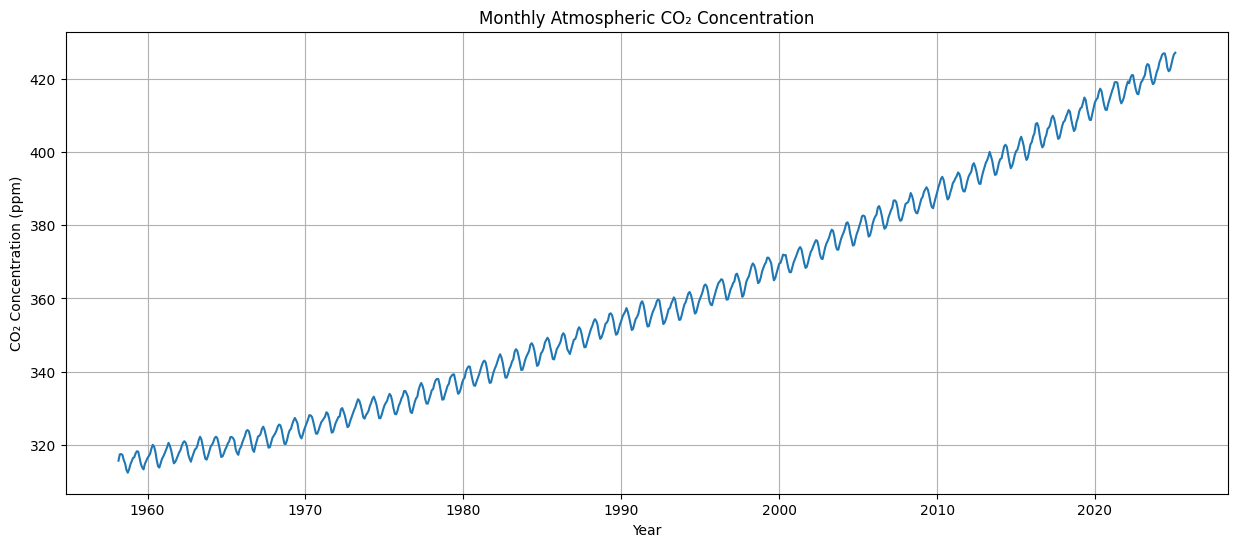

In [8]:
plt.figure(figsize=(15, 6))

plt.plot(df.index, df['CO2'])

plt.title('Monthly Atmospheric CO₂ Concentration')
plt.xlabel('Year')
plt.ylabel('CO₂ Concentration (ppm)')
plt.grid(True)

plt.show()

In [9]:
df['Moving_Average_12'] = df['CO2'].rolling(window=12).mean()

df.head(15)

,CO2,Moving_Average_12
date,,
1958-03-01,315.71,NaN
1958-04-01,317.45,NaN
1958-05-01,317.51,NaN
1958-06-01,317.27,NaN
1958-07-01,315.87,NaN
1958-08-01,314.93,NaN
1958-09-01,313.21,NaN
1958-10-01,312.42,NaN
1958-11-01,313.33,NaN


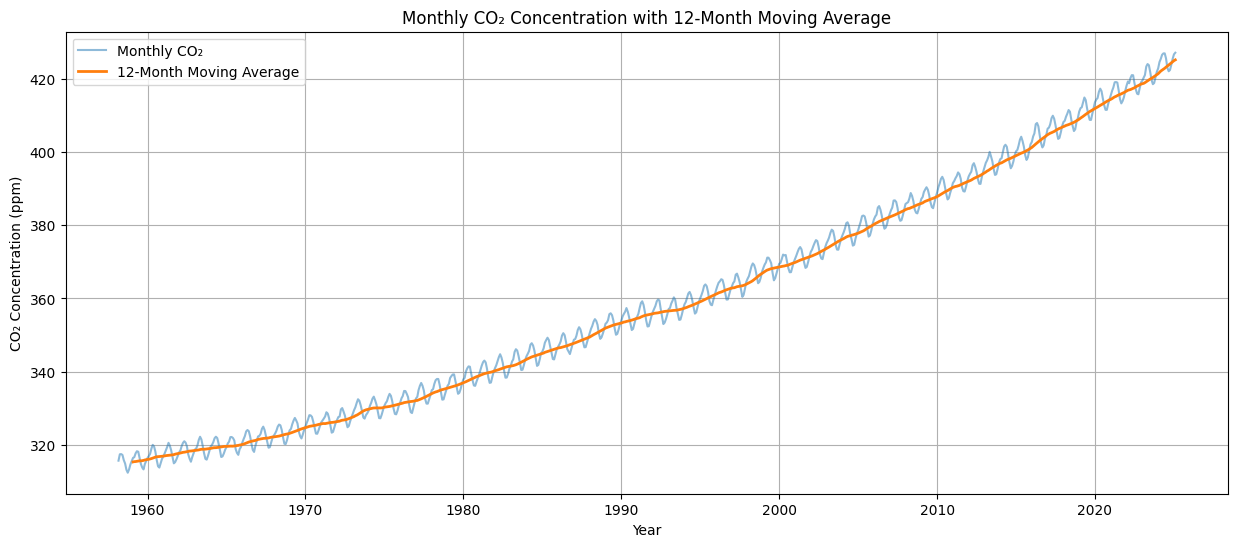

In [10]:
plt.figure(figsize=(15, 6))

plt.plot(df.index, df['CO2'], label='Monthly CO₂', alpha=0.5)
plt.plot(df.index, df['Moving_Average_12'],
         label='12-Month Moving Average',
         linewidth=2)

plt.title('Monthly CO₂ Concentration with 12-Month Moving Average')
plt.xlabel('Year')
plt.ylabel('CO₂ Concentration (ppm)')

plt.legend()
plt.grid(True)

plt.show()

In [11]:
decomposition = seasonal_decompose(
    df['CO2'],
    model='additive',
    period=12
)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

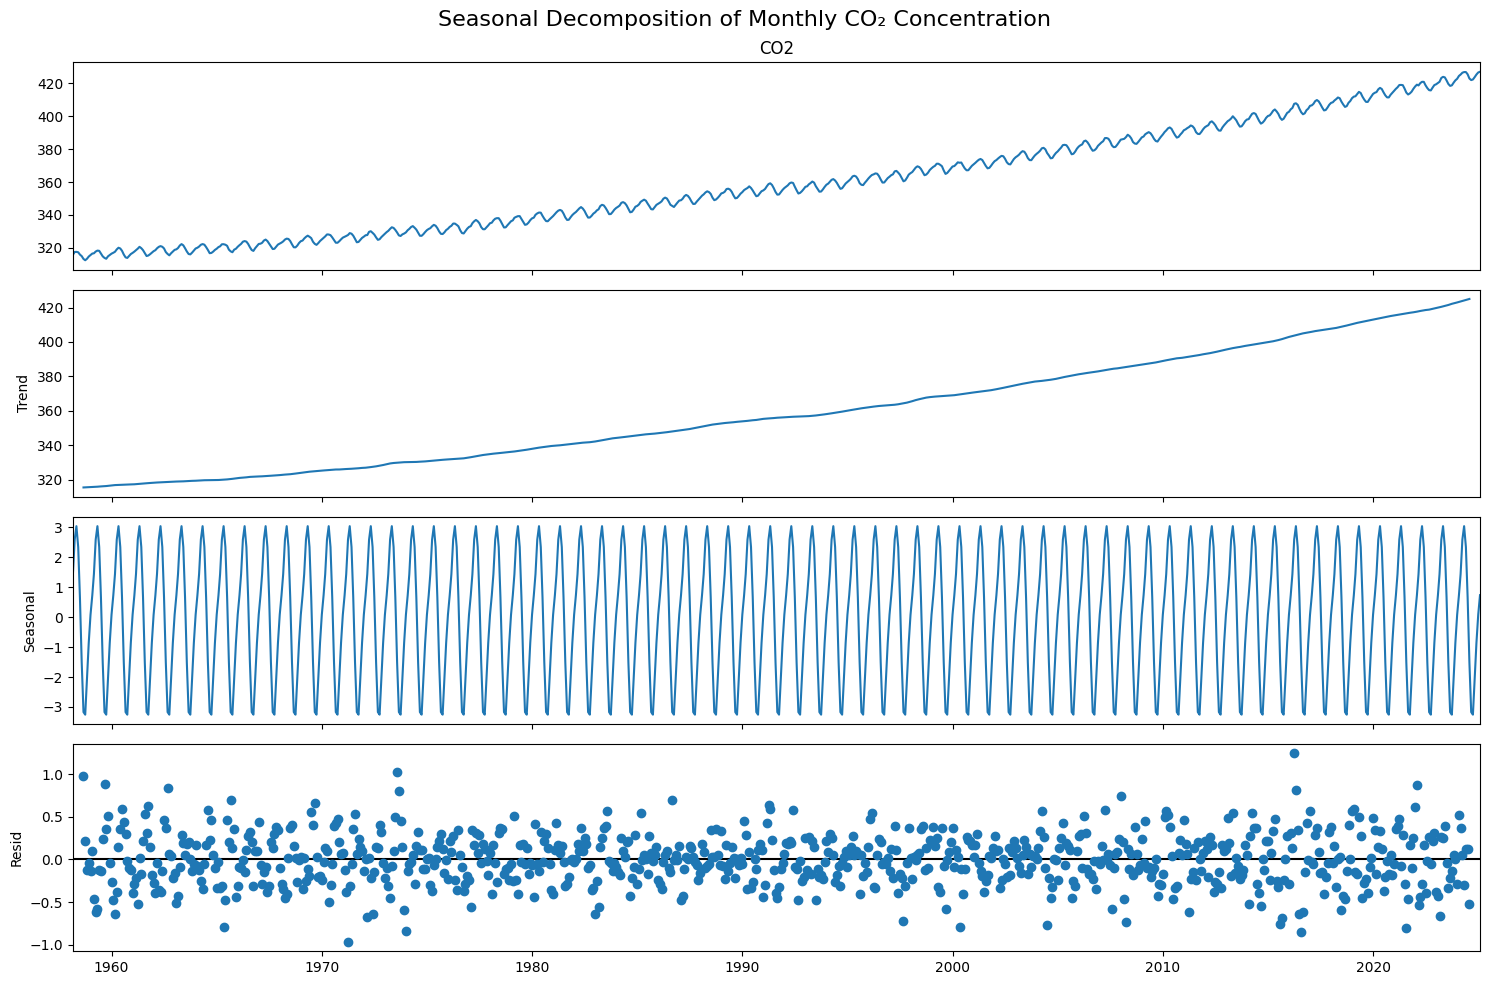

In [12]:
fig = decomposition.plot()

fig.set_size_inches(15, 10)

plt.suptitle(
    'Seasonal Decomposition of Monthly CO₂ Concentration',
    fontsize=16
)

plt.tight_layout()
plt.show()

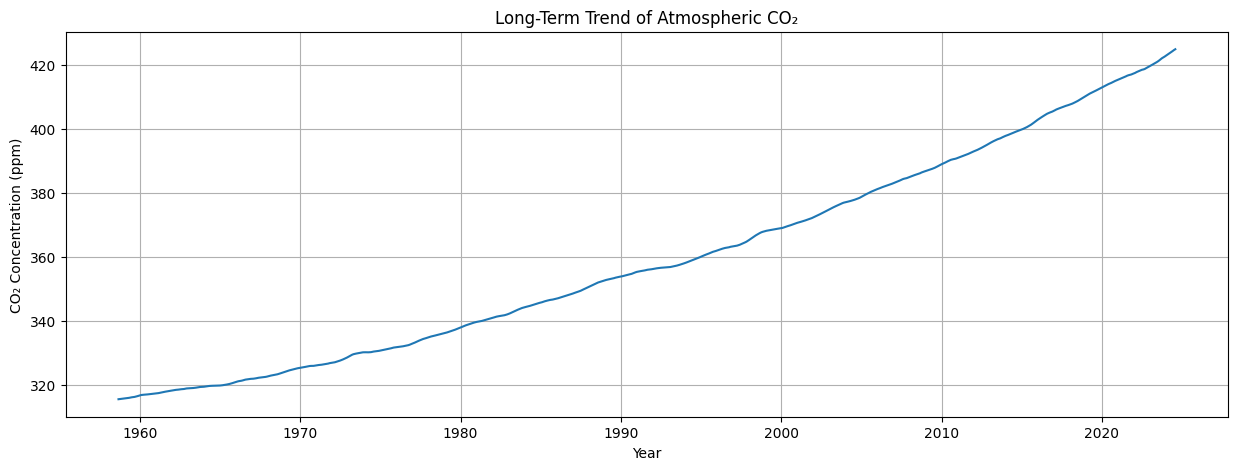

In [13]:
plt.figure(figsize=(15, 5))

plt.plot(trend)

plt.title('Long-Term Trend of Atmospheric CO₂')
plt.xlabel('Year')
plt.ylabel('CO₂ Concentration (ppm)')
plt.grid(True)

plt.show()

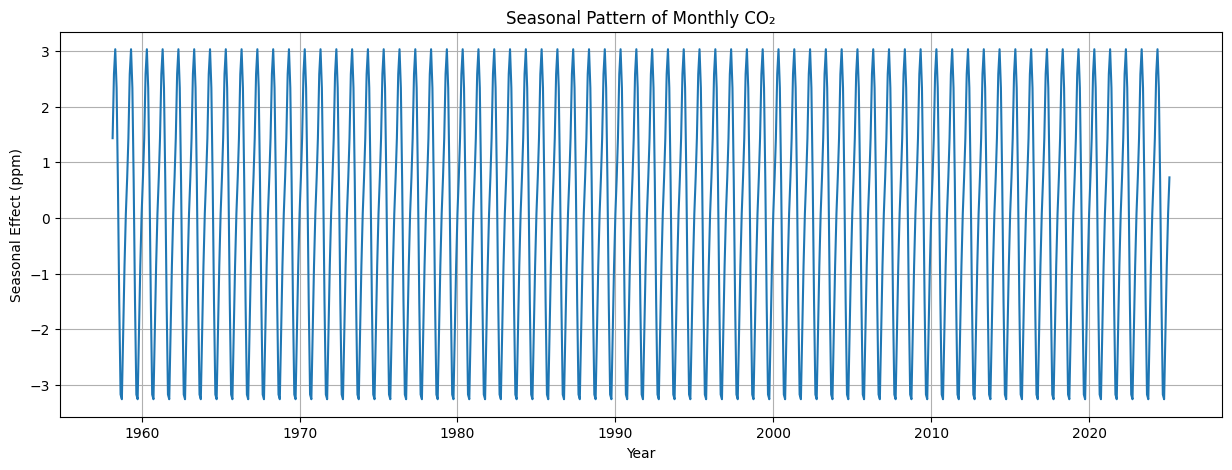

In [14]:
plt.figure(figsize=(15, 5))

plt.plot(seasonal)

plt.title('Seasonal Pattern of Monthly CO₂')
plt.xlabel('Year')
plt.ylabel('Seasonal Effect (ppm)')
plt.grid(True)

plt.show()

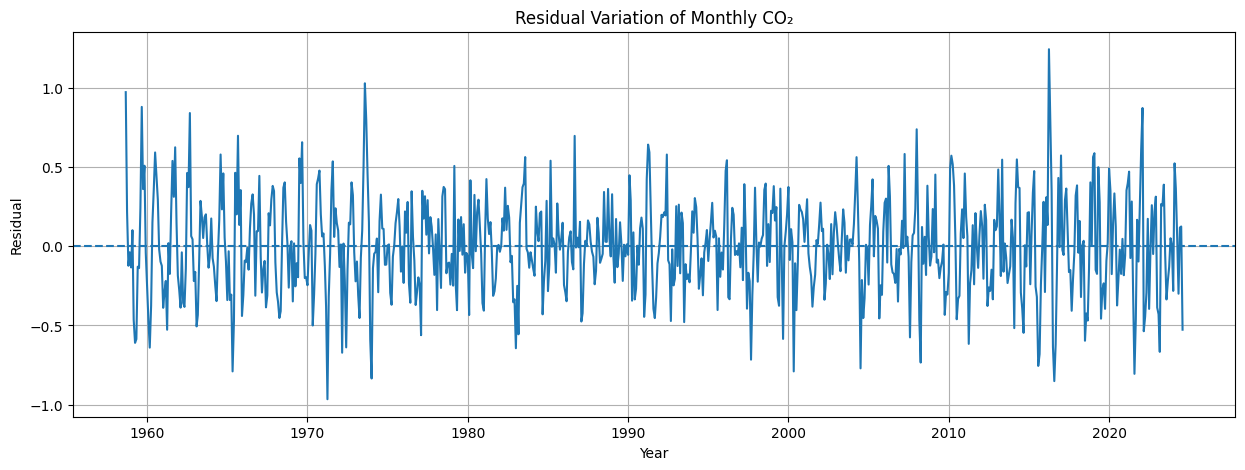

In [15]:
plt.figure(figsize=(15, 5))

plt.plot(residual)

plt.axhline(y=0, linestyle='--')

plt.title('Residual Variation of Monthly CO₂')
plt.xlabel('Year')
plt.ylabel('Residual')
plt.grid(True)

plt.show()

In [16]:
seasonal_df = pd.DataFrame({
    'Seasonal_Effect': seasonal
})

seasonal_df['Month'] = seasonal_df.index.month

monthly_seasonal_effect = seasonal_df.groupby(
    'Month'
)['Seasonal_Effect'].mean()

monthly_seasonal_effect

,Seasonal_Effect
Month,
1,0.076969
2,0.729658
3,1.433496
4,2.585226
5,3.031792
6,2.335750
7,0.661331
8,-1.514067
9,-3.170601


In [17]:
month_names = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_seasonal_effect.index = month_names

print("Average Seasonal Effect for Each Month:")
display(monthly_seasonal_effect)

Average Seasonal Effect for Each Month:


,Seasonal_Effect
January,0.076969
February,0.729658
March,1.433496
April,2.585226
May,3.031792
June,2.335750
July,0.661331
August,-1.514067
September,-3.170601
October,-3.255658


In [18]:
monthly_average_co2 = df.copy()

monthly_average_co2['Month'] = monthly_average_co2.index.month

monthly_average_co2 = monthly_average_co2.groupby(
    'Month'
)['CO2'].mean()

monthly_average_co2.index = month_names

print("Average CO₂ Concentration by Month:")
display(monthly_average_co2)

Average CO₂ Concentration by Month:


,CO2
January,360.565373
February,361.350299
March,360.516119
April,361.812687
May,362.390597
June,361.838955
July,360.306567
August,358.287463
September,356.752836
October,356.810299


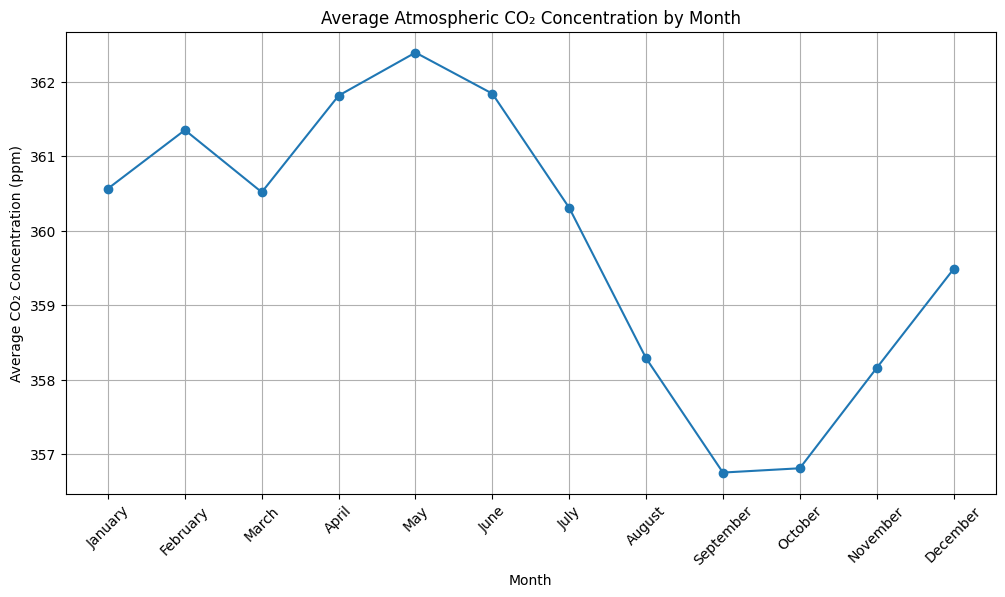

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_average_co2.index,
    monthly_average_co2.values,
    marker='o'
)

plt.title('Average Atmospheric CO₂ Concentration by Month')
plt.xlabel('Month')
plt.ylabel('Average CO₂ Concentration (ppm)')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

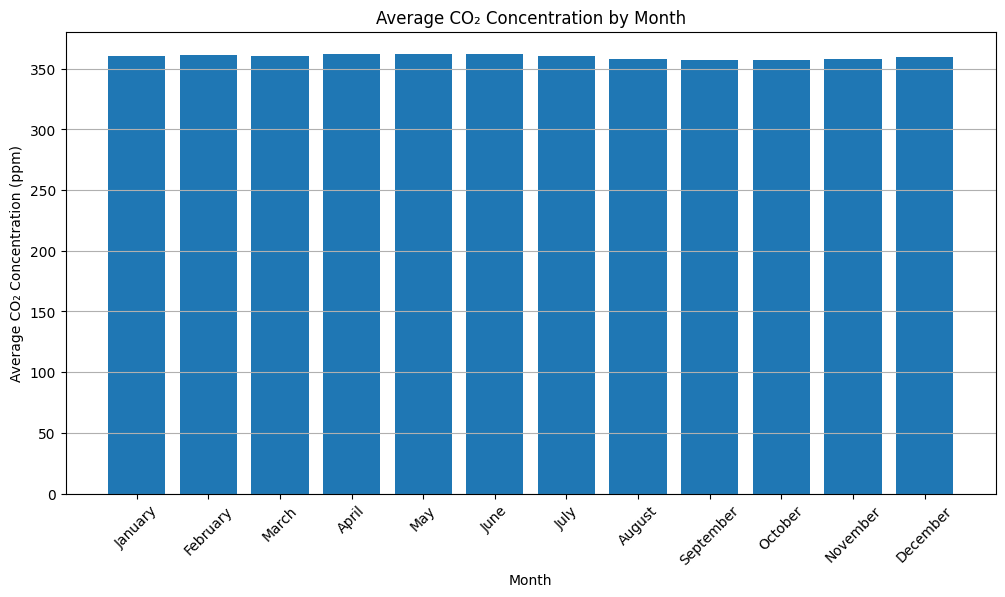

In [20]:
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_average_co2.index,
    monthly_average_co2.values
)

plt.title('Average CO₂ Concentration by Month')
plt.xlabel('Month')
plt.ylabel('Average CO₂ Concentration (ppm)')

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()